#Austo Automobiles

##Context -
Analysts are required to explore data and reflect on the insights. Clear writing skill is an integral part of a good report. Note that the explanations must be such that readers with minimum knowledge of analytics is able to grasp the insight.

Austo Motor Company is a leading car manufacturer specializing in SUV, Sedan, and Hatchback models. In its recent board meeting, concerns were raised by the members on the efficiency of the marketing campaign currently being used. The board decides to rope in an analytics professional to improve the existing campaign.

##Objective -
They want to analyze the data to get a fair idea about the demand of customers which will help them in enhancing their customer experience. Suppose you are a Data Scientist at the company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

#1. Data Overview

1.1 Import Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1.2 Load the Data

In [69]:
df = pd.read_csv('/content/austo_automobile .csv')

1.3 Check the Structure of the Data

In [70]:
# Shape of dataset (rows, columns)
print(f"Dataset Shape: {df.shape}")

# First 5 rows
print(df.head())

Dataset Shape: (1581, 14)
   Age  Gender Profession Marital_status      Education  No_of_Dependents  \
0   53    Male   Business        Married  Post Graduate                 4   
1   53   Femal   Salaried        Married  Post Graduate                 4   
2   53  Female   Salaried        Married  Post Graduate                 3   
3   53  Female   Salaried        Married       Graduate                 2   
4   53    Male   Salaried        Married  Post Graduate                 3   

  Personal_loan House_loan Partner_working  Salary  Partner_salary  \
0            No         No             Yes   99300         70700.0   
1           Yes         No             Yes   95500         70300.0   
2            No         No             Yes   97300         60700.0   
3           Yes         No             Yes   72500         70300.0   
4            No         No             Yes   79700         60200.0   

   Total_salary  Price Make  
0        170000  61000  SUV  
1        165800  61000  SUV  


* The dataset contains 1581 rows and 14 columns.
* It includes a mix of numerical variables (such as Age, Salary, Partner_salary, Total_salary, Price, and No_of_Dependents) and categorical variables (such as Gender, Profession, Marital_status, Education, Make, Personal_loan, House_loan, and Partner_working).

1.4 Check the Data Types

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB



* Numerical columns are correctly represented as integers or floats.
* Categorical columns are of type object as expected.
* The dataset information confirms proper data types for further analysis.

1.5 Check for and Treat Missing Values

In [41]:
display(df.isnull().sum())

,0
Age,0
Gender,53
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


Missing values were found in:
* Gender: 53 missing entries.
* Partner_salary: 106 missing entries.

In [42]:
# Clean the Gender column by replacing 'Femal' with 'Female'
df['Gender'] = df['Gender'].replace({'Femal': 'Female' , 'Femle': 'Female'})
# Fill missing values in 'Gender' with the mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
# Display value counts for Gender to confirm cleaning
display(df['Gender'].value_counts())

,count
Gender,
Male,1252
Female,329


* Gender missing values filled using the mode ('Male').
* Typo was present in the Gender column:'Femal' and 'Femle' are corrected to 'Female'.

In [43]:
#Fill missing values in 'Partner_salary' with 0
df['Partner_salary'] = df['Total_salary'] - df['Salary']
df['Partner_salary']

,Partner_salary
0,70700
1,70300
2,60700
3,70300
4,60200
...,...
1576,0
1577,0
1578,0
1579,0


Partner_salary = Total_salary - Salary, by this we can find the missing values of the Partner_salary. (OR) below is an another method of filling the missing value.

In [72]:
# Another way of Fill missing values in 'Partner_salary' with 0
df['Partner_salary'] = df['Partner_salary'].fillna(0)

* Partner_salary missing values filled with 0, assuming no partner income.

In [45]:
# Drop duplicate rows if present
df = df.drop_duplicates()
# Display the updated info to confirm changes
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1581 non-null   int64 
 1   Gender            1581 non-null   object
 2   Profession        1581 non-null   object
 3   Marital_status    1581 non-null   object
 4   Education         1581 non-null   object
 5   No_of_Dependents  1581 non-null   int64 
 6   Personal_loan     1581 non-null   object
 7   House_loan        1581 non-null   object
 8   Partner_working   1581 non-null   object
 9   Salary            1581 non-null   int64 
 10  Partner_salary    1581 non-null   int64 
 11  Total_salary      1581 non-null   int64 
 12  Price             1581 non-null   int64 
 13  Make              1581 non-null   object
dtypes: int64(6), object(8)
memory usage: 173.1+ KB


None

* Duplicate records were checked and removed. 0 duplicate rows were present originally, and no further action was required.
* After treatment, no missing values remain.

1.6 Statistical Summary

In [73]:
# Statistical summary of numerical columns
print (df.describe())

# Categorical columns summary
print(df.describe(include=['object']))

               Age  No_of_Dependents        Salary  Partner_salary  \
count  1581.000000       1581.000000   1581.000000     1581.000000   
mean     31.922201          2.457938  60392.220114    18869.512966   
std       8.425978          0.943483  14674.825044    19570.644035   
min      22.000000          0.000000  30000.000000        0.000000   
25%      25.000000          2.000000  51900.000000        0.000000   
50%      29.000000          2.000000  59500.000000    24900.000000   
75%      38.000000          3.000000  71800.000000    38000.000000   
max      54.000000          4.000000  99300.000000    80500.000000   

        Total_salary         Price  
count    1581.000000   1581.000000  
mean    79625.996205  35597.722960  
std     25545.857768  13633.636545  
min     30000.000000  18000.000000  
25%     60500.000000  25000.000000  
50%     78000.000000  31000.000000  
75%     95900.000000  47000.000000  
max    171000.000000  70000.000000  
       Gender Profession Marital_sta

* The average Age of customers is approximately 31.92 years.
* The average Total Salary of customers is about ₹79,626.
* The average Car Price is approximately ₹35,598.
* The most common Profession is 'Salaried'.
* The most frequent Car Make is 'Sedan'.

# 2. Univariate Analysis

2.1 Explore all the variables in the data

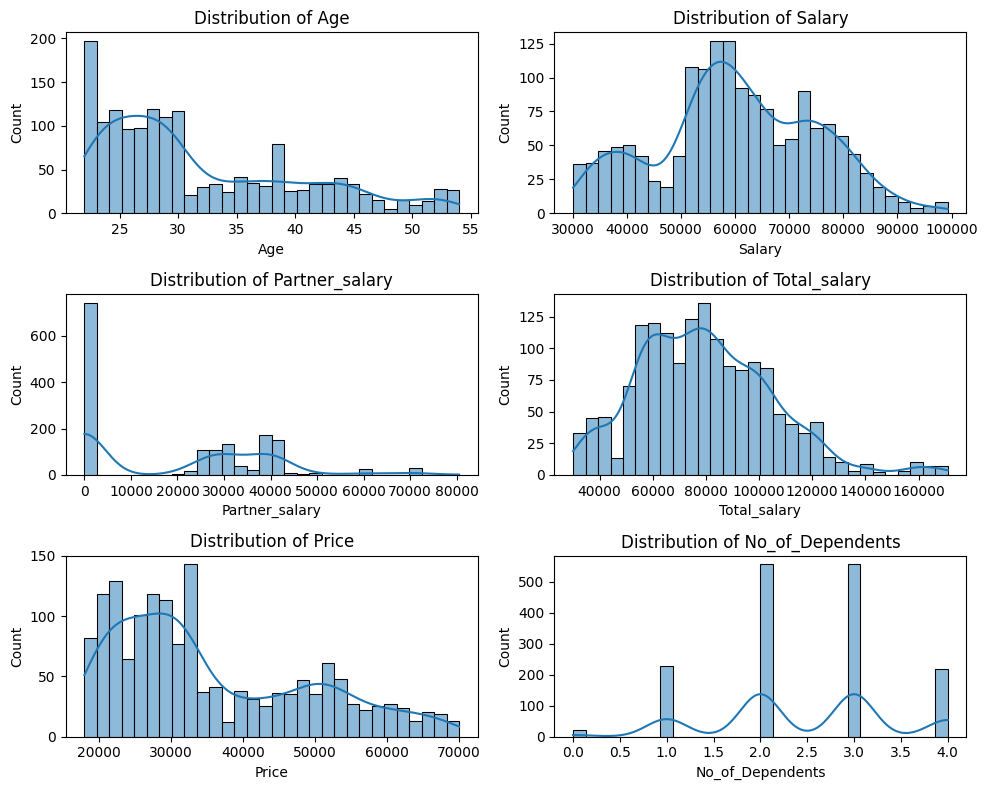

In [47]:
# Plot distribution of numerical variables
numerical_cols = ['Age', 'Salary', 'Partner_salary', 'Total_salary', 'Price', 'No_of_Dependents']

plt.figure(figsize=(10, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

* The distribution of Age is right-skewed, with most customers between 25 and 40 years.
* Salary, Partner_salary, and Total_salary are also right-skewed, indicating a small number of high-income customers.
* Price shows right-skewness, which is common as expensive cars are fewer.
* Number of Dependents is mostly between 0 to 3, with very few customers having more than that.

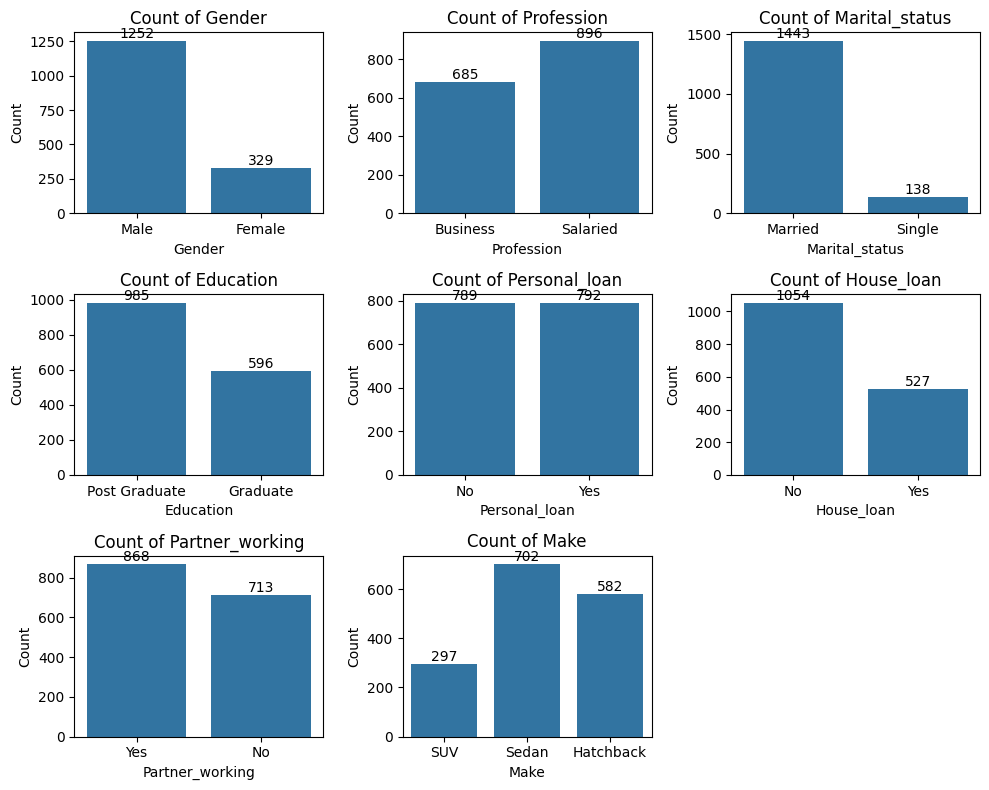

In [48]:
# Plot distribution of categorical variables
categorical_cols = ['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working', 'Make']

plt.figure(figsize=(10, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    ax = sns.countplot(data=df, x=col)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

     # Add count labels on top of bars
    for container in ax.containers:
        ax.bar_label(container)
plt.tight_layout()
plt.show()

* Most customers are Male.
* The dominant profession is Salaried, followed by Business.
* Majority are Married and most of their education is Post Graduation degree.
* Almost half the customers have Personal and few customers have House Loans.
* Most partners are working.
* The most common car type (Make) is Sedan, followed by Hatchback and SUV.

2.2 Check for and Treat Outliers

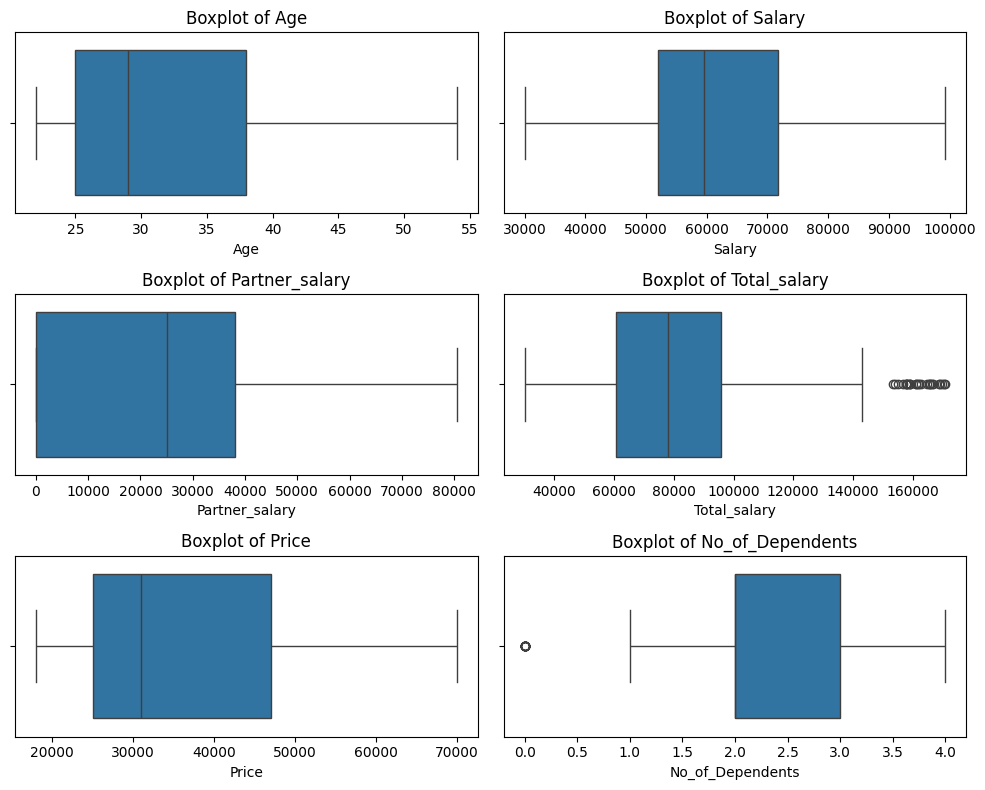

In [49]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(['Age', 'Salary', 'Partner_salary', 'Total_salary', 'Price', 'No_of_Dependents'], 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

* The dataset shows that most customers are aged between 25 and 40 years, with salaries ranging from ₹30,000 to ₹100,000 and Car Price distribution is mostly uniform, ranging from ₹20,000 to ₹70,000. With no extreme outliers in these variables, indicating a balanced spread of data.
* Partner_salary is highly skewed, with many customers having no partner income. But no outliers to be treated.
* There were extreme outliers in Total_salary (above ₹160,000) got to be treated.
* The Number of Dependents mostly ranges between 0 and 3, which is typical for individual or small family structures, and valid 0 dependents are not treated as outliers.

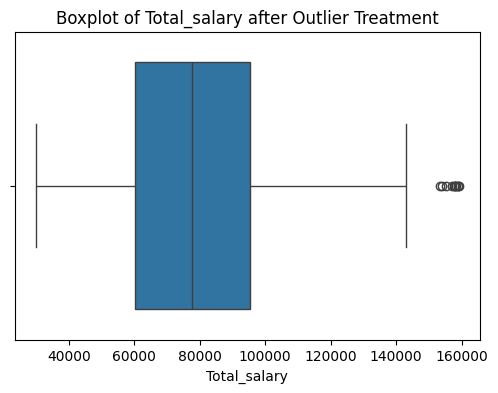

In [50]:
# Treatment of Outliers
# Calculate the 99th percentile threshold for Total_salary
total_salary_upper_limit = df['Total_salary'].quantile(0.99)

# Filter the dataframe to remove extreme outliers
df = df[df['Total_salary'] <= total_salary_upper_limit]

# Confirm no extreme outliers remain in Total_salary
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Total_salary'])
plt.title('Boxplot of Total_salary after Outlier Treatment')
plt.show()


# 3. Bivariate Analysis

3.1 Explore all the relationship between all numerical variables.

* Extreme outliers in Total_salary were successfully treated by removing values above the 99th percentile.
* Remaining data points represent valid high-income customers, so no further action is needed.

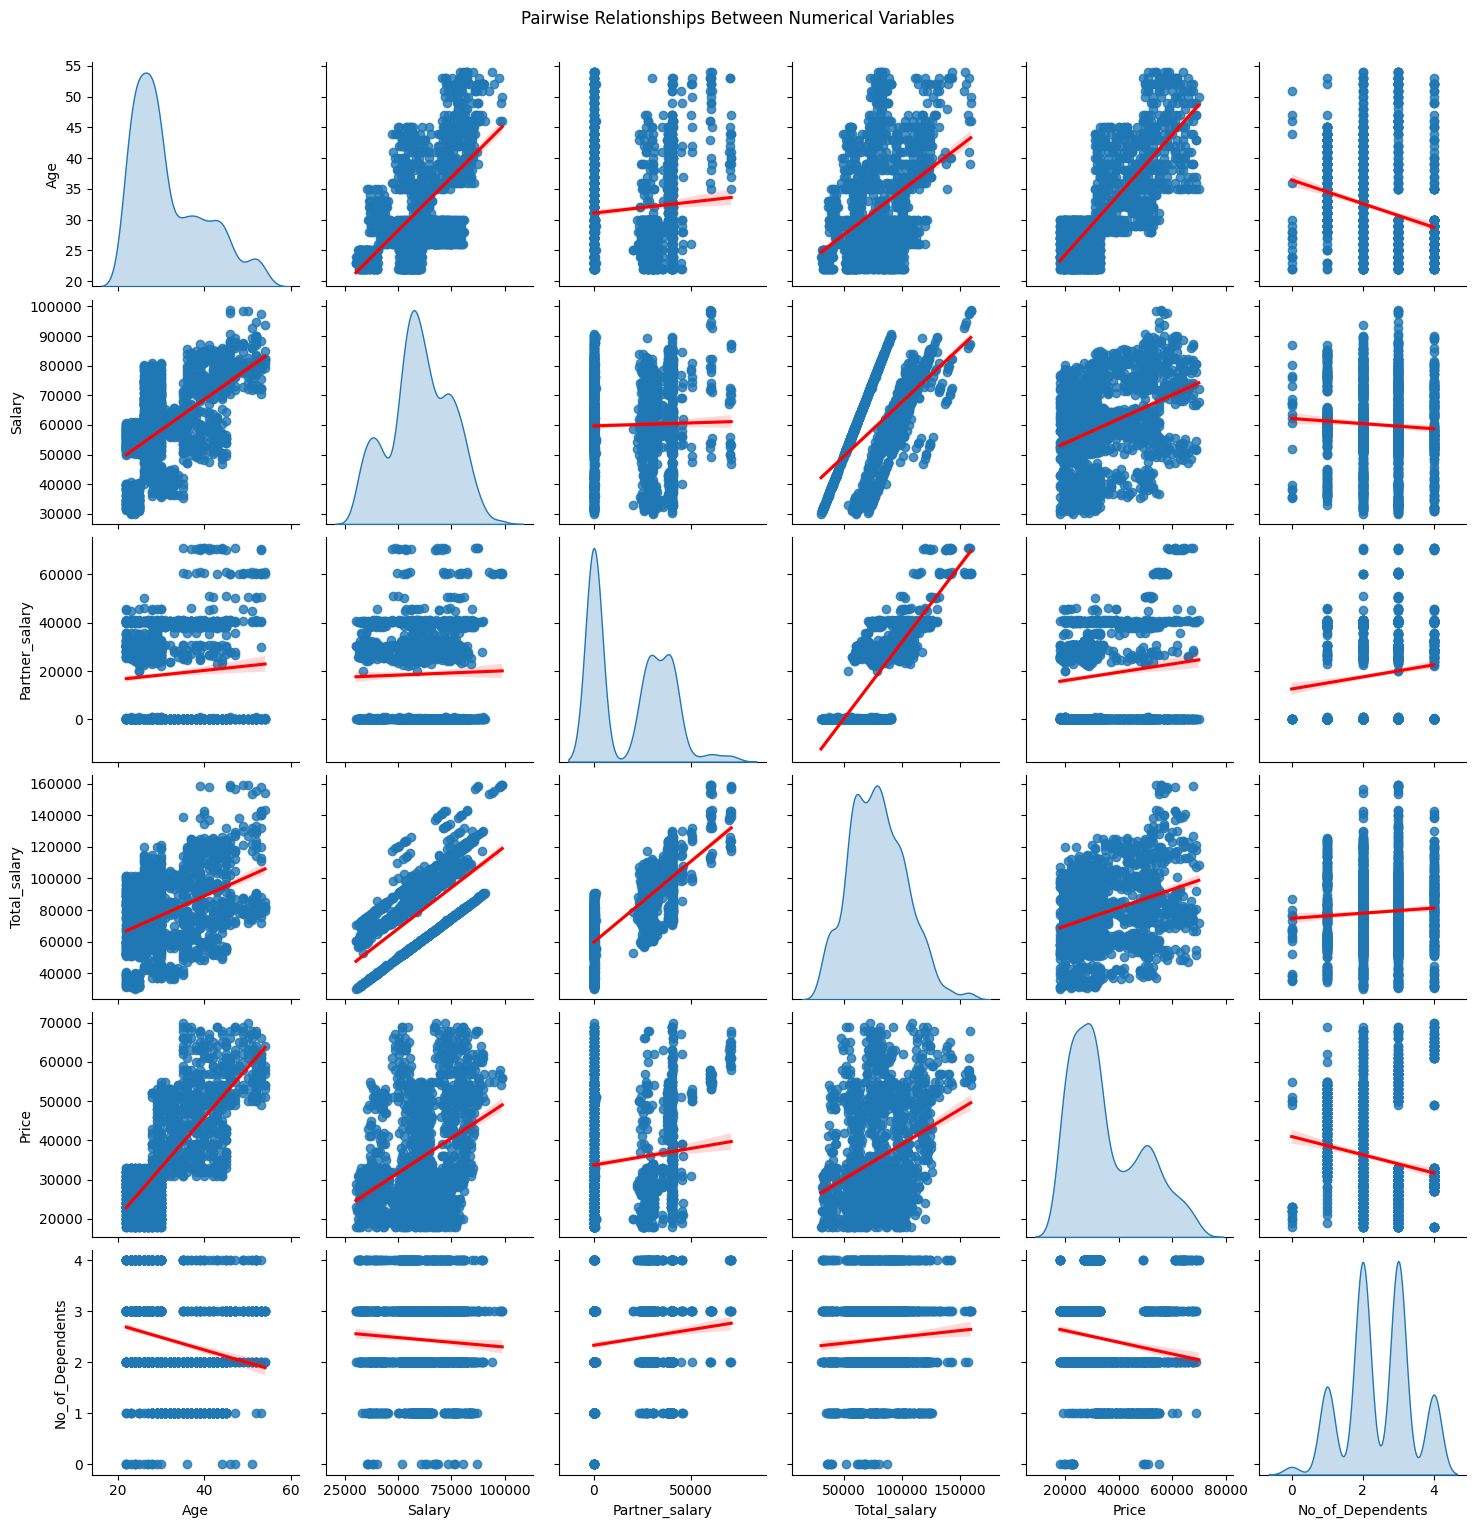

In [51]:
# Pairplot to visualize relationships between numerical variables
sns.pairplot(df[['Age', 'Salary', 'Partner_salary', 'Total_salary', 'Price', 'No_of_Dependents']], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Pairwise Relationships Between Numerical Variables', y=1.02)
plt.show()


* There is a positive relationship between Salary, Partner_salary, and Total_salary.
* A moderate positive relationship between Total_salary and Price suggests customers with higher total income tend to purchase more expensive cars.
* A strong positive relationship between Age and Price indicates that older customers generally prefer higher-priced cars.
* No strong relationship between Number of Dependents and other numerical variables, suggesting dependents are independent of salary, age, or price.

3.2 Explore the correlation between all numerical variables

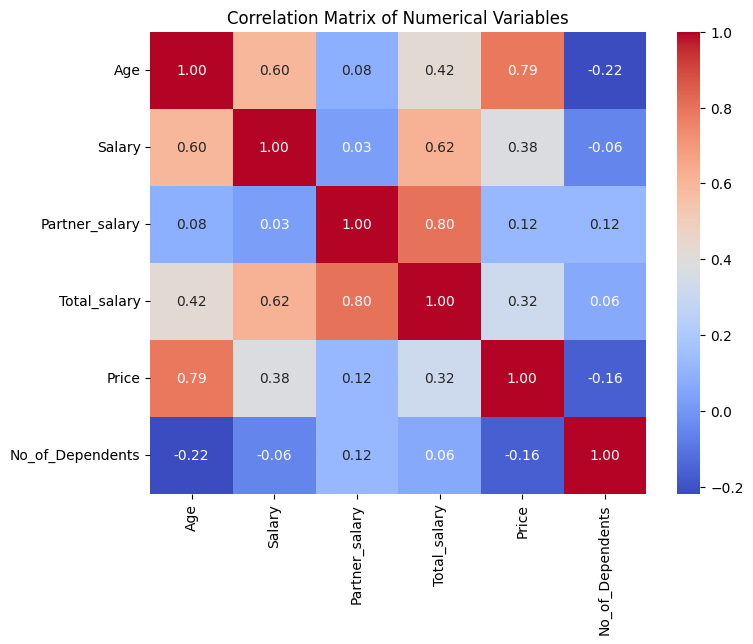

In [52]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

* Strong correlation (0.79) between Age and Price, confirming that older individuals tend to purchase costlier cars.
* Strong correlation (0.80) between Partner_salary and Total_salary, reinforcing that Partner_salary plays a major role in determining Total_salary.
* Moderate correlation (0.42) between Age and Total_salary, indicating older individuals generally have higher total income.
* Moderate correlation (0.38) between Salary and Price, implying customers with higher salary are more likely to buy higher-priced cars.
* Very weak or negligible correlation between Number of Dependents and other numerical variables (around -0.2 to 0.12), indicating number of dependents does not significantly affect financial variables or car price.

3.3 Categorical vs Numerical Variables

3.3.1 Car Make vs Numerical variables

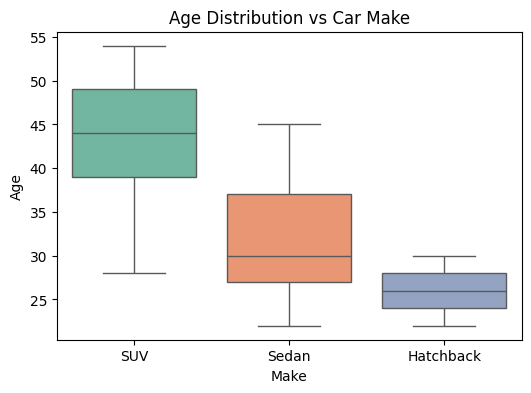

In [53]:
#Car Make vs Age
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Make', y='Age', hue = 'Make', palette='Set2')
plt.title('Age Distribution vs Car Make')
plt.show()

SUV buyers are generally older (median age ~ 44 years) compared to Sedan (~ 30 years) and Hatchback (~27 years) buyers. This shows that SUV owners tend to be older, Sedan by 30's and Hatchback by youngest.

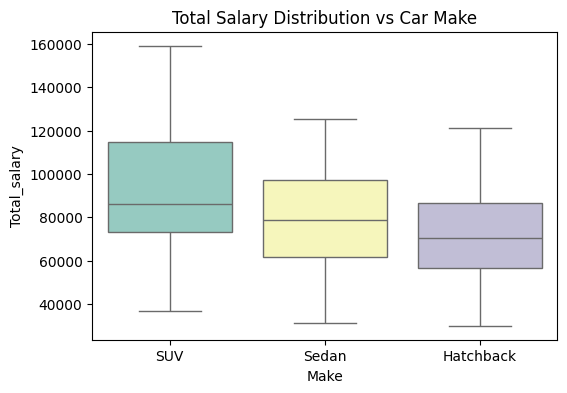

In [54]:
#Car make vs Total Salary
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Make', y='Total_salary', hue = 'Make', palette='Set3')
plt.title('Total Salary Distribution vs Car Make')
plt.show()

SUV buyers have significantly higher Total Salary (~₹85,000 median with range 40,000 - 1,60,000) than Sedan or Hatchback buyers.

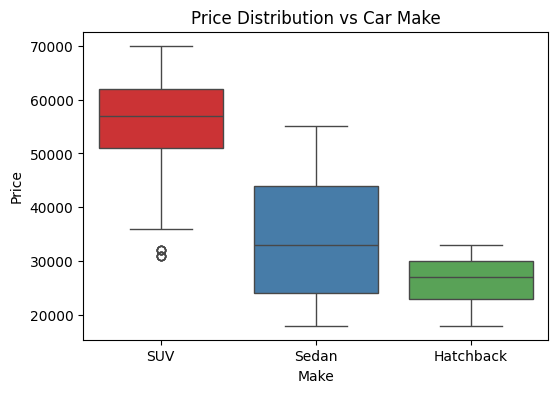

In [55]:
#Price vs Make
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Make', y='Price', hue = 'Make', palette='Set1')
plt.title('Price Distribution vs Car Make')
plt.show()

* The Price of SUVs is higher on average (~ ₹60,000) compared to Sedans (~ ₹35,000) and Hatchbacks (~₹25,000).

SUV tends to be more expensive than Sedans and Hatchbacks. Sedans have a wider range of prices compared to Hatchbacks. And Hatchbacks generally have the lowest prices.

3.3.2 Personal Loan/ House loan vs Price and total Salary.

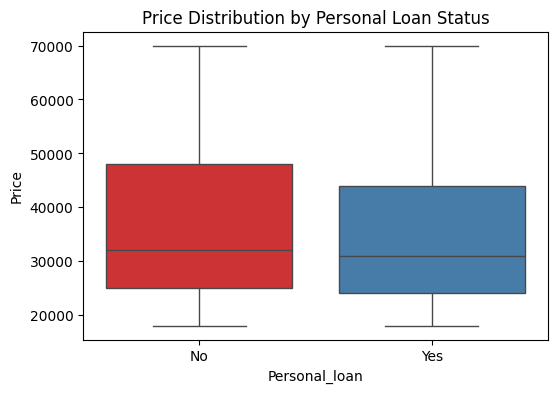

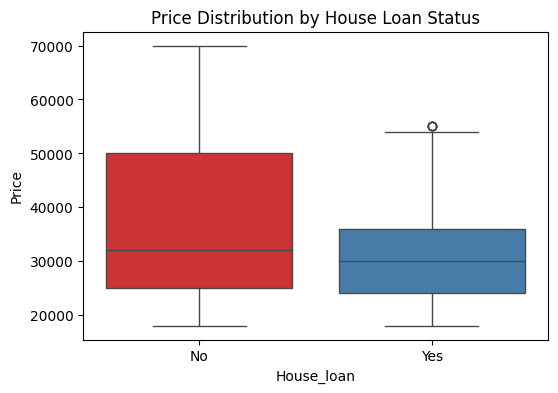

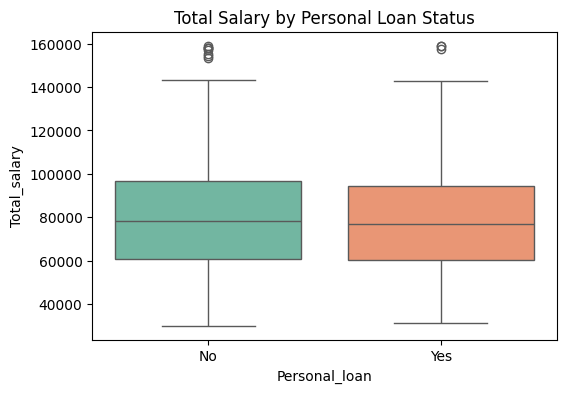

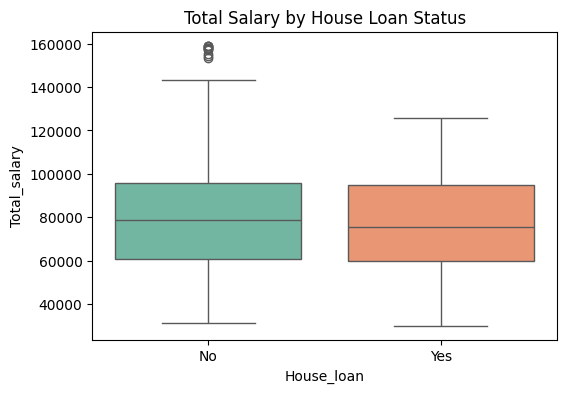

In [56]:
# Personal Loan vs Price
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Personal_loan', y='Price', hue = 'Personal_loan', palette='Set1')
plt.title('Price Distribution by Personal Loan Status')
plt.show()

# House Loan vs Price
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='House_loan', y='Price',hue = 'House_loan', palette='Set1')
plt.title('Price Distribution by House Loan Status')
plt.show()

# Personal Loan vs Total Salary
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Personal_loan', y='Total_salary', hue = 'Personal_loan', palette='Set2')
plt.title('Total Salary by Personal Loan Status')
plt.show()

# House Loan vs Total Salary
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='House_loan', y='Total_salary', hue = 'House_loan', palette='Set2')
plt.title('Total Salary by House Loan Status')
plt.show()

* No significant difference in Car Price distribution based on Personal Loan. But customers with a house loan tend to have lower price car compared to those without a house loan.
* Total salary distribution are similar whether you have a personal loan or not. But people with a house loan tend to have higher total salaries.


3.3.3 Gender vs Salary and Price

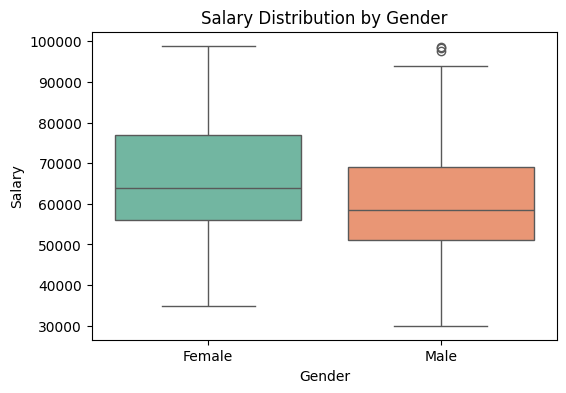

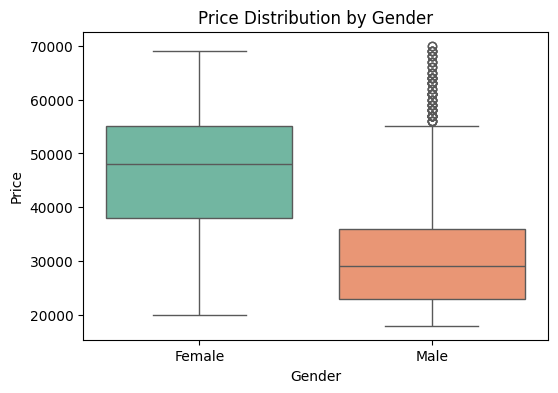

In [57]:
#Salary vs Gender
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Gender', y='Salary', hue = 'Gender', palette='Set2')
plt.title('Salary Distribution by Gender')
plt.show()

#Price vs Gender
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Gender', y='Price', hue = 'Gender', palette='Set2')
plt.title('Price Distribution by Gender')
plt.show()


* Salary distribution is fairly similar across Male and Female customers.

* Females are associated with a high price range car, which could indiacte differences in spending habits. A few outliers with high range price car purchased by Male than the usual range.

3.3.4 Marital Status vs Total Salary and Price

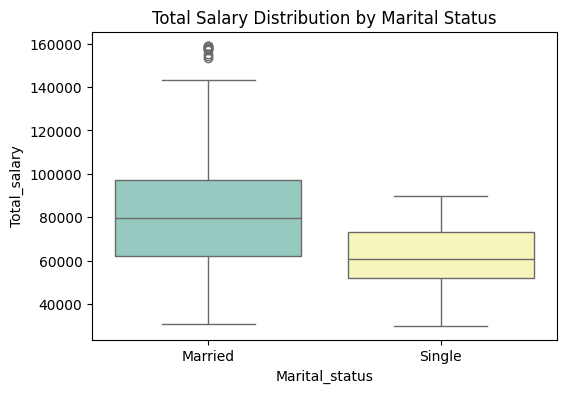

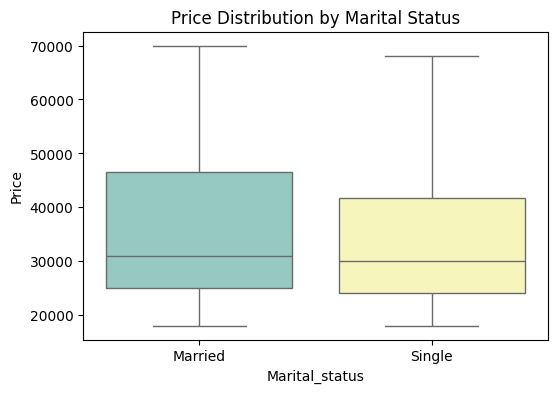

In [58]:
#Total salary vs Marital Status
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Marital_status', y='Total_salary', hue = 'Marital_status', palette='Set3')
plt.title('Total Salary Distribution by Marital Status')
plt.show()

#Price vs Marital Status
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Marital_status', y='Price', hue = 'Marital_status', palette='Set3')
plt.title('Price Distribution by Marital Status')
plt.show()


* Married customers tend to have a higher Total Salary (~ ₹80,000 median) than Single customers (~ ₹60,000 median).
* Price distribution look somewhat similar for both married and single. Car Price does not vary significantly based on Marital Status, indicating marital status is not a primary factor in car price decision

## Key Questions
Q1) Do men tend to prefer SUVs more compared to women?

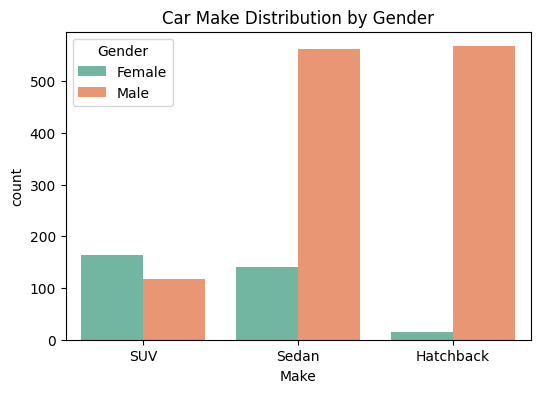

In [59]:
# Count plot of Make vs Gender
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Make', hue='Gender', palette='Set2')
plt.title('Car Make Distribution by Gender')
plt.show()

No, men don't tend to prefer SUV's more compared to women, they prefer Sedan and Hatchback more compared to women.

Q2) What is the likelihood of a salaried person buying a Sedan?

The likelihood of a salaried person buying a Sedan is: 44.6449%


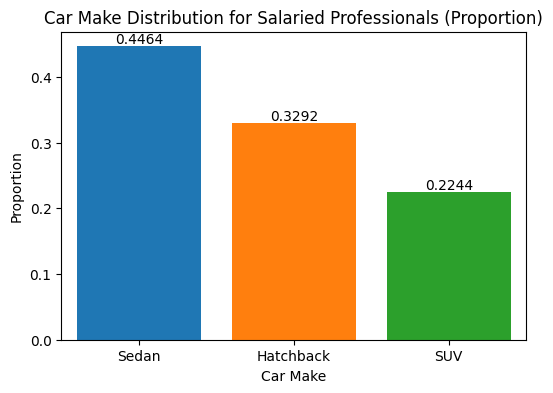

In [60]:
# Calculate the proportion of each car make for salaried professionals
salaried_make_counts = df[df['Profession'] == 'Salaried']['Make'].value_counts()
salaried_make_proportions = salaried_make_counts / salaried_make_counts.sum()

# Print the likelihood of a salaried person buying a Sedan
print(f"The likelihood of a salaried person buying a Sedan is: {salaried_make_proportions['Sedan']:.4%}")

# Plot the distribution of car makes for salaried professionals as proportions
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=salaried_make_proportions.index,
                 y=salaried_make_proportions.values)
plt.title('Car Make Distribution for Salaried Professionals (Proportion)')
plt.xlabel('Car Make')
plt.ylabel('Proportion')

# Define a list of different colors for each bar
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Using a standard set of distinct colors

# Iterate through the bars and set their colors
for i, patch in enumerate(ax.patches):
    patch.set_facecolor(colors[i % len(colors)])

# Add percentage labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', label_type='edge')

plt.show()

In [61]:
# The likelihood of a salaried person buying a Sedan can also found by calculating it.
# Total salaried professionals
total_salaried = df[df['Profession'] == 'Salaried'].shape[0]

# Salaried professionals who bought Sedan
sedan_salaried = df[(df['Profession'] == 'Salaried') & (df['Make'] == 'Sedan')].shape[0]

# Likelihood (probability)
likelihood_sedan_salaried = (sedan_salaried / total_salaried)
likelihood_sedan_salaried

0.4464487034949267

Salaried people have a 44.64% chance of buying a Sedan car.

Q3) What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?

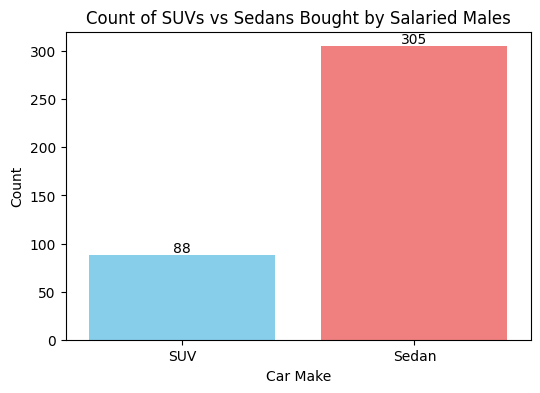

In [62]:
# Count of SUVs vs Sedans by Salaried Males
suv_count = df[(df['Gender'] == 'Male') & (df['Profession'] == 'Salaried') & (df['Make'] == 'SUV')].shape[0]
sedan_count = df[(df['Gender'] == 'Male') & (df['Profession'] == 'Salaried') & (df['Make'] == 'Sedan')].shape[0]

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Car Make': ['SUV', 'Sedan'],
    'Count': [suv_count, sedan_count]
})

# Create the bar plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=plot_data, x='Car Make', y='Count')
plt.title('Count of SUVs vs Sedans Bought by Salaried Males')
plt.xlabel('Car Make')
plt.ylabel('Count')

# Define a list of different colors for each bar
colors = ['skyblue', 'lightcoral']

# Iterate through the bars and set their colors
for i, patch in enumerate(ax.patches):
    patch.set_facecolor(colors[i % len(colors)])


# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

The data does not support Sheldon Cooper's claim that a salaried male is an easier target for an SUV sale over a Sedan sale. Instead, it indicates a strong prefrence for Sedan among Salaried males.

Q4) How does the amount spent on purchasing automobiles vary by gender?

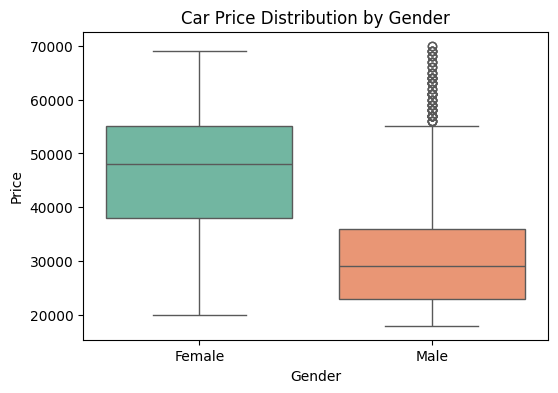

In [63]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Gender', y='Price', hue = 'Gender', palette='Set2')
plt.title('Car Price Distribution by Gender')
plt.show()

In [64]:
# Group by Gender and calculate stats
gender_price_stats = df.groupby("Gender")["Price"].agg(
    ["count", "mean", "median", "min", "max", "std"]
).reset_index()

gender_price_stats

,Gender,count,mean,median,min,max,std
0,Female,319,47181.818182,48000.0,20000,69000,10998.778455
1,Male,1246,32259.229535,29000.0,18000,70000,12184.698709


* Females: Higher median price, more variability.
* Males: Lower median price, less variability.
So, Females spend more on purchasing automobiles compared to men.

The outliers indicate that some males purchased cars at significantly higher price, deviating than the usual range.

Q5) How much money was spent on purchasing automobiles by individuals who took a personal loan?

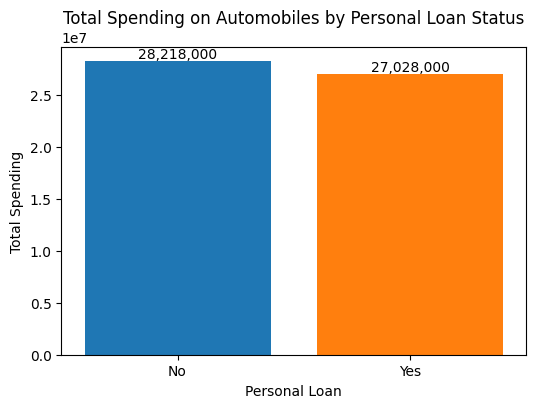

In [65]:
# Calculate total spending on cars by personal loan status
personal_loan_spending_comparison = df.groupby('Personal_loan')['Price'].sum().reset_index()

# Create a bar plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=personal_loan_spending_comparison, x='Personal_loan', y='Price')
plt.title('Total Spending on Automobiles by Personal Loan Status')
plt.xlabel('Personal Loan')
plt.ylabel('Total Spending')

# Define a list of different colors for each bar
colors = ['#1f77b4', '#ff7f0e'] # Two colors for the two bars

# Iterate through the bars and set their colors
for i, patch in enumerate(ax.patches):
    patch.set_facecolor(colors[i % len(colors)])

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.show()

The total sum (2,70,28,000) indicates how much was spent by personal loan holders.

Q6) How does having a working partner influence the purchase of higher-priced cars?

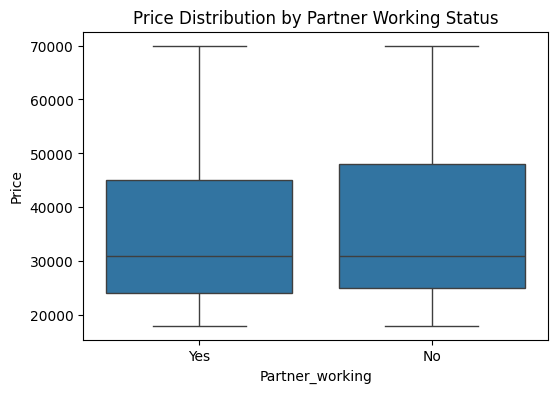

In [66]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Partner_working', y='Price')
plt.title('Price Distribution by Partner Working Status')
plt.show()

In [67]:
# Group by Partner Working Status
partner_price_stats = df.groupby("Partner_working")["Price"].agg(
    ["count", "mean", "median", "min", "max", "std", "sum"]
).reset_index()

partner_price_stats


,Partner_working,count,mean,median,min,max,std,sum
0,No,713,36000.000000,31000.0,18000,70000,13817.734086,25668000
1,Yes,852,34715.962441,31000.0,18000,70000,12975.854958,29578000


* The median price is the same (₹31,000) for both 'No' and 'Yes' partner working status.
* The mean price is slightly higher for partners not working (₹36,000) compared to those working (₹34,715).

But overall, having a working partner doesn't indicate a tendency to buy higher-priced cars.

#Actionable Insights
1.	Demographics
* Majority of buyers are young (25–40 years) and salaried professionals.
* Married individuals dominate the dataset, showing that family needs are a strong purchase driver.
2.	Car Preferences
* Sedans are the most popular choice, especially among salaried individuals.
* SUV buyers are generally older (~40+ years) with higher household incomes.
* Hatchbacks attract younger and budget-conscious buyers.
3.	Financial Factors
* Customers with house loans often buy lower-priced cars, even if they have higher total salaries.
* Personal loan holders account for significant spending (₹2.7 crores in total), indicating finance is an important enabler.
* Female buyers spend more per car on average compared to males.
4.	Spending Behaviour
* Average car price is ~₹35,600, indicating a mid-market focus.
* Double-income households (working partners) do not always buy higher-priced cars, suggesting other priorities limit spending.

#Business Recommendations
1. Product Strategy
* Focus production on Sedans as the mass-market product.
* Expand SUV offerings for older, higher-income customers seeking premium features.
* Keep Hatchbacks affordable to attract first-time and budget-conscious buyers.
2. Marketing Strategy
* Segment campaigns by age and income:
o	Young professionals (Sedans, affordable Hatchbacks).
o	Mature households (SUVs, premium Sedans).
* Create women-focused campaigns (safety, comfort, premium options) since female buyers spend more per purchase.
* Use family-oriented messaging for married customers who dominate the market.
3. Financial & Pricing Strategy
* Offer special finance packages for customers with house loans to ease affordability.
* Partner with banks for personal loan + car loan bundled schemes to encourage purchases.
4. Sales & After-Sales Strategy
* Promote value-for-money service packages for Sedan buyers.
* Design loyalty programs targeting repeat customers and family referrals.
* Ensure premium after-sales service for SUV owners to build brand trust.

________________________________________________________________________________
